# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')

Matplotlib is building the font cache; this may take a moment.


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)
df.head

<bound method NDFrame.head of              PRIMARY_KEY          STATE  YEAR  ENROLL_ALL_EST  TOTAL_REVENUE  \
0           1992_ALABAMA        ALABAMA  1992             NaN      2678885.0   
1            1992_ALASKA         ALASKA  1992             NaN      1049591.0   
2           1992_ARIZONA        ARIZONA  1992             NaN      3258079.0   
3          1992_ARKANSAS       ARKANSAS  1992             NaN      1711959.0   
4        1992_CALIFORNIA     CALIFORNIA  1992             NaN     26260025.0   
...                  ...            ...   ...             ...            ...   
1710       2019_VIRGINIA       VIRGINIA  2019             NaN            NaN   
1711     2019_WASHINGTON     WASHINGTON  2019             NaN            NaN   
1712  2019_WEST_VIRGINIA  WEST_VIRGINIA  2019             NaN            NaN   
1713      2019_WISCONSIN      WISCONSIN  2019             NaN            NaN   
1714        2019_WYOMING        WYOMING  2019             NaN            NaN   

      FED

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *Grade 8 Math*

How many years of data are logged in our dataset? 

In [15]:
# @@@ 1
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

print(df['YEAR'].unique())
Years = df['YEAR'].unique()
print(Years[-1] - Years[0])

[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 1986 1987 1988
 1989 1990 1991 2017 2019]
27


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [21]:
# @@@ 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)
print(df.loc[df['STATE'] == 'MICHIGAN', 'AVG_MATH_8_SCORE'].mean())
print(df.loc[df['STATE'] == 'OHIO', 'AVG_MATH_8_SCORE'].mean())

276.1666666666667
282.25


Find the average for your chosen test across all states in 2019

In [23]:
# @@@ 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)
print(df.loc[(df['YEAR'] == 2019), 'AVG_MATH_8_SCORE'].mean())


281.2641509433962


For each state, find a maximum value for your chosen test score

In [24]:
# @@@ 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)
print(df.loc[(df['YEAR'] == 2019), 'AVG_MATH_8_SCORE'].mean())

281.2641509433962


*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [30]:
# @@@ 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
df['Year_over_Year_Expenditure'] = df.groupby('STATE')['Expenditure_per_student'].pct_change() * 100
print(df.loc[df['STATE'] == 'MICHIGAN', 'Year_over_Year_Expenditure'].mean())
print(df.loc[df['STATE'] == 'OHIO', 'Expenditure_per_student'].mean())


2.833839528136571
10.482668132538162
2.196084565466596


Feature engineering justification: **<I chose to create Expenditure Per Student and Year Over Year Expenditure to show what each state is investing in each student, and how much their budget is growing per year.>**

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

Text(0.5, 1.0, '8th Grade Math Score vs Expenditure per Student')

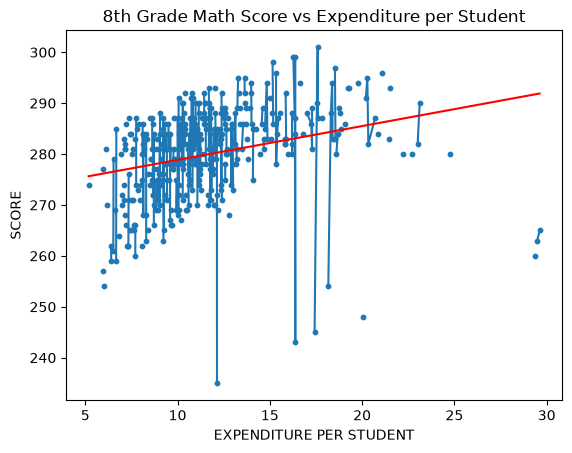

In [43]:
# @@@ 6
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
df['Year_over_Year_Expenditure'] = df.groupby('STATE')['Expenditure_per_student'].pct_change() * 100
grouped = df.groupby('Expenditure_per_student')["AVG_MATH_8_SCORE"].mean().plot()
grouped = df.groupby('Expenditure_per_student')['AVG_MATH_8_SCORE'].mean().dropna()
x = grouped.index.values
y = grouped.values
plt.scatter(x, y, label='data', s=10)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='red', label='trend')
plt.ylabel('SCORE')
plt.xlabel('EXPENDITURE PER STUDENT')
plt.title('8th Grade Math Score vs Expenditure per Student')

**<This graph a positive trend between expenditure per student and 8th grade math score.>**

**Visualization 2**

Text(0.5, 1.0, '8th Grade Math Score vs Year-over-Year Expenditure')

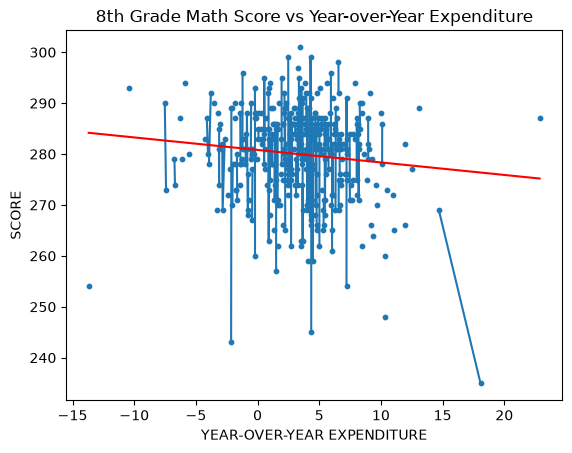

In [44]:
# @@@ 7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
df['Year_over_Year_Expenditure'] = df.groupby('STATE')['Expenditure_per_student'].pct_change() * 100
grouped = df.groupby('Year_over_Year_Expenditure')["AVG_MATH_8_SCORE"].mean().plot()
grouped = df.groupby('Year_over_Year_Expenditure')['AVG_MATH_8_SCORE'].mean().dropna()
x = grouped.index.values
y = grouped.values
plt.scatter(x, y, label='data', s=10)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='red', label='trend')
plt.ylabel('SCORE')
plt.xlabel('YEAR-OVER-YEAR EXPENDITURE')
plt.title('8th Grade Math Score vs Year-over-Year Expenditure')

**<Even though the line is going down, the trend is mostly flat due to a lot of scatter within the data. But it doesnt seem like there is a large correlation between Year Over Year Expenditure and 8th grade math exam scores.>**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# @@@ 8

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']

X = df[['Expenditure_per_student']]
y = df['AVG_MATH_8_SCORE']
y.fillna(y.median(), inplace=True)

In [45]:
# @@@ 9 

# X_train, X_test, y_train, y_test = train_test_split(
#      X, y, test_size=, random_state=42)
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']

X = df[['Expenditure_per_student']]
y = df['AVG_MATH_8_SCORE']
y.fillna(y.median(), inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [ ]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [ ]:
# @@@ 11
# create your model here
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']

X = df[['Expenditure_per_student']]
y = df['AVG_MATH_8_SCORE']
y.fillna(y.median(), inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
model = LinearRegression()

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
model_df = df.dropna(subset=['Expenditure_per_student', 'AVG_MATH_8_SCORE'])
X = model_df[['Expenditure_per_student']]
y = model_df['AVG_MATH_8_SCORE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.52]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Expenditure_per_student']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,273.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
model_df = df.dropna(subset=['Expenditure_per_student', 'AVG_MATH_8_SCORE'])
X = model_df[['Expenditure_per_student']]
y = model_df['AVG_MATH_8_SCORE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Predicted Scores: {y_pred}")

Predicted Scores: [278.25016511 278.20098857 278.2755518  279.90453237 277.99092072
 278.87957683 280.68874468 279.03372555 277.41294133 280.77520289
 280.89549319 279.78178181 278.48091432 279.29128336 283.34027434
 278.99651445 280.63301333 279.54012213 277.17965384 280.34374779
 280.02825042 281.22425007 284.59021325 277.4304568  278.2793516
 279.60048232 284.37494874 280.66463871 280.22984088 278.62693921
 280.18459312 278.40149818 277.66319838 279.74982799 279.40843014
 279.14116624 278.48954009 280.99476283 283.62374648 279.33443657
 277.76429886 277.22769579 279.02413112 279.59489573 277.63565098
 278.59433122 278.24970526 279.53185557 279.99035891 278.82808044
 278.99389841 280.18936657 283.85943442 277.39784761 278.27687546
 277.60899012 278.41927587 278.74836829 283.39046554 279.29206344
 282.80875551 279.94492829 278.31503954 278.30821944 278.79351575
 278.90378    280.1124976  280.13041646 280.56599399 277.6004632
 284.12444499 278.02294302 277.60438185 279.35646321 278.373

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [ ]:
# @@@ 12
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
model_df = df.dropna(subset=['Expenditure_per_student', 'AVG_MATH_8_SCORE'])
X = model_df[['Expenditure_per_student']]
y = model_df['AVG_MATH_8_SCORE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Model Coefficient: {model.coef_[0]}")
print(f"Model R^2 Score: {model.score(X_test, y_test)}")

Model Coefficient: 0.5233045046529708
Model Intercept: 273.76138299075325
Model R^2 Score: 0.13931866363422152


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

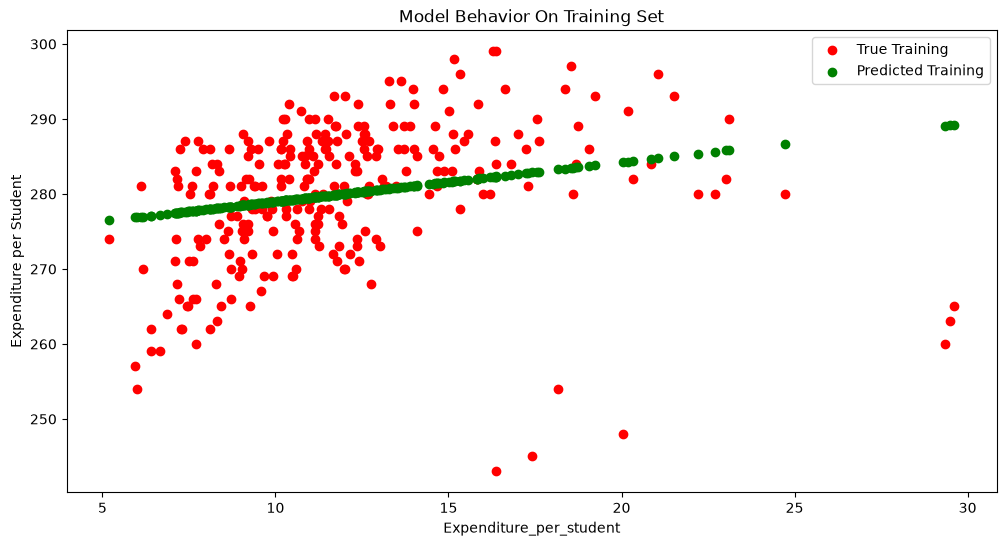

In [57]:
# @@@ 13
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/states_edu.csv')
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df['Expenditure_per_student'] = df['TOTAL_EXPENDITURE'] / df['ENROLL_ALL_EST']
model_df = df.dropna(subset=['Expenditure_per_student', 'AVG_MATH_8_SCORE'])
X = model_df[['Expenditure_per_student']]
y = model_df['AVG_MATH_8_SCORE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

col_name = 'Expenditure_per_student'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Expenditure per Student')
plt.title("Model Behavior On Training Set")

In [ ]:
# @@@ 14


# col_name = 'COLUMN NAME OF ONE PREDICTOR"


# f = plt.figure(figsize=(12,6))
# plt.scatter(X_test[col_name], y_test, color = "blue")
# plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

# plt.legend(['True testing','Predicted testing'])
# plt.xlabel(col_name)
# plt.ylabel('NAME OF THE PREDICTOR')
# plt.title("Model Behavior on Testing Set")